# Importing libraries and data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , VotingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , classification_report , confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout , Dense , Input
from tensorflow.keras import regularizers
from scikeras.wrappers import KerasClassifier

In [ ]:
df_train = pd.read_csv('/home/kyburg/kaggle/input/spaceship-titanic/train.csv')
df_test = pd.read_csv('/home/kyburg/kaggle/input/spaceship-titanic/test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
df_train.info()

Train shape: (8693, 14)
Test shape: (4277, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


# EDA (Exloratory Data Analysis)

In [ ]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
def eda(df, subplots_rows, subplots_cols, plot_conf):
    df = df.copy()
    if len(plot_conf) > subplots_rows * subplots_cols:
        print(f'More plot configurations ({len(plot_conf)}) were given than subplots')
        print(f'Using only the first {subplots_rows * subplots_cols} configurations')
        plot_conf = plot_conf[:subplots_rows * subplots_cols]
    fig, axes = plt.subplots(subplots_rows, subplots_cols, figsize=(20, 20))
    for i in range(subplots_rows):
        for j in range(subplots_cols):
            try:
                current_conf = plot_conf[i * subplots_cols + j]
            except:
                continue
            if current_conf['Plot'] == 'pivot_heatmap':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.pivot_table(
                    values = current_conf['values'],
                    index = current_conf['index'],
                    columns = current_conf['columns'],
                    aggfunc = aggfunc
                )
                annot = current_conf['annot'] if 'annot' in current_conf.keys() else True
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=annot, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'boxplot':
                data = [df.dropna()[df[current_conf['columns']] == m][current_conf['values']].values 
                        for m in pd.unique(df[current_conf['columns']].dropna())]
                labels = pd.unique(df[current_conf['columns']].dropna())
                axes[i, j].boxplot(data, tick_labels=labels)
            elif current_conf['Plot'] == 'hist':
                nbins = current_conf['bins'] if 'bins' in current_conf.keys() else 10
                df[current_conf['columns']].hist(bins=nbins, ax=axes[i,j])
            elif current_conf['Plot'] == 'barh':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'mean'
                data = df.groupby(current_conf['columns'])[current_conf['values']].agg(aggfunc).sort_values(ascending=False)
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'steelblue'
                axes[i, j].barh(range(len(data)), data.values, color=colormap)
            elif current_conf['Plot'] == 'corr':
                data = df[current_conf['columns']].corr()
                colormap = current_conf['colormap'] if 'colormap' in current_conf.keys() else 'coolwarm'
                sns.heatmap(data, annot=True, cmap=colormap, ax=axes[i,j])
            elif current_conf['Plot'] == 'scatter':
                if 'values' in current_conf.keys():
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], hue=current_conf['values'], legend='full', ax=axes[i,j])
                else:
                    sns.scatterplot(data=df, x=current_conf['index'], y=current_conf['columns'], legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'discrete_scatter':
                aggfunc = current_conf['agg_function'] if 'agg_function' in current_conf.keys() else 'sum'
                data = df.groupby([current_conf['columns']] + [current_conf['index']], as_index=False)[current_conf['values']].agg(aggfunc)
                sns.scatterplot(data=data, x=current_conf['index'], y=current_conf['columns'], size=current_conf['values'], sizes=(50,500), legend='full', ax=axes[i,j])
            elif current_conf['Plot'] == 'bar':
                df.groupby(current_conf['columns']).size().unstack().plot.bar(ax=axes[i,j])
            elif current_conf['Plot'] == 'kde':
                for m in  pd.unique(df[current_conf['columns']].dropna()):
                    df[df[current_conf['columns']] == m][current_conf['values']].plot.kde(ax=axes[i,j], label=m)
                axes[i,j].legend()
            else:
                print(f"Unrecognized plot: '{current_conf['Plot']}'\n{'-' * 10} Skipping {'-' * 10}")
            if 'title' in current_conf.keys():
                axes[i, j].set_title(current_conf['title'], fontweight='bold')
            if 'set_ylabel' in current_conf.keys():
                axes[i, j].set_ylabel(current_conf['set_ylabel'], fontweight='bold')
            if 'set_xlabel' in current_conf.keys():
                axes[i, j].set_xlabel(current_conf['set_xlabel'], fontweight='bold')
            if 'set_yticks' in current_conf.keys() and current_conf['set_yticks']:
                axes[i, j].set_yticks(range(len(data)))
            if 'set_yticklabels' in current_conf.keys() and current_conf['set_yticklabels']:
                axes[i, j].set_yticklabels(data.index)
            if 'grid' in current_conf.keys():
                axes[i, j].grid(axis=current_conf['grid'][0], alpha=current_conf['grid'][1])

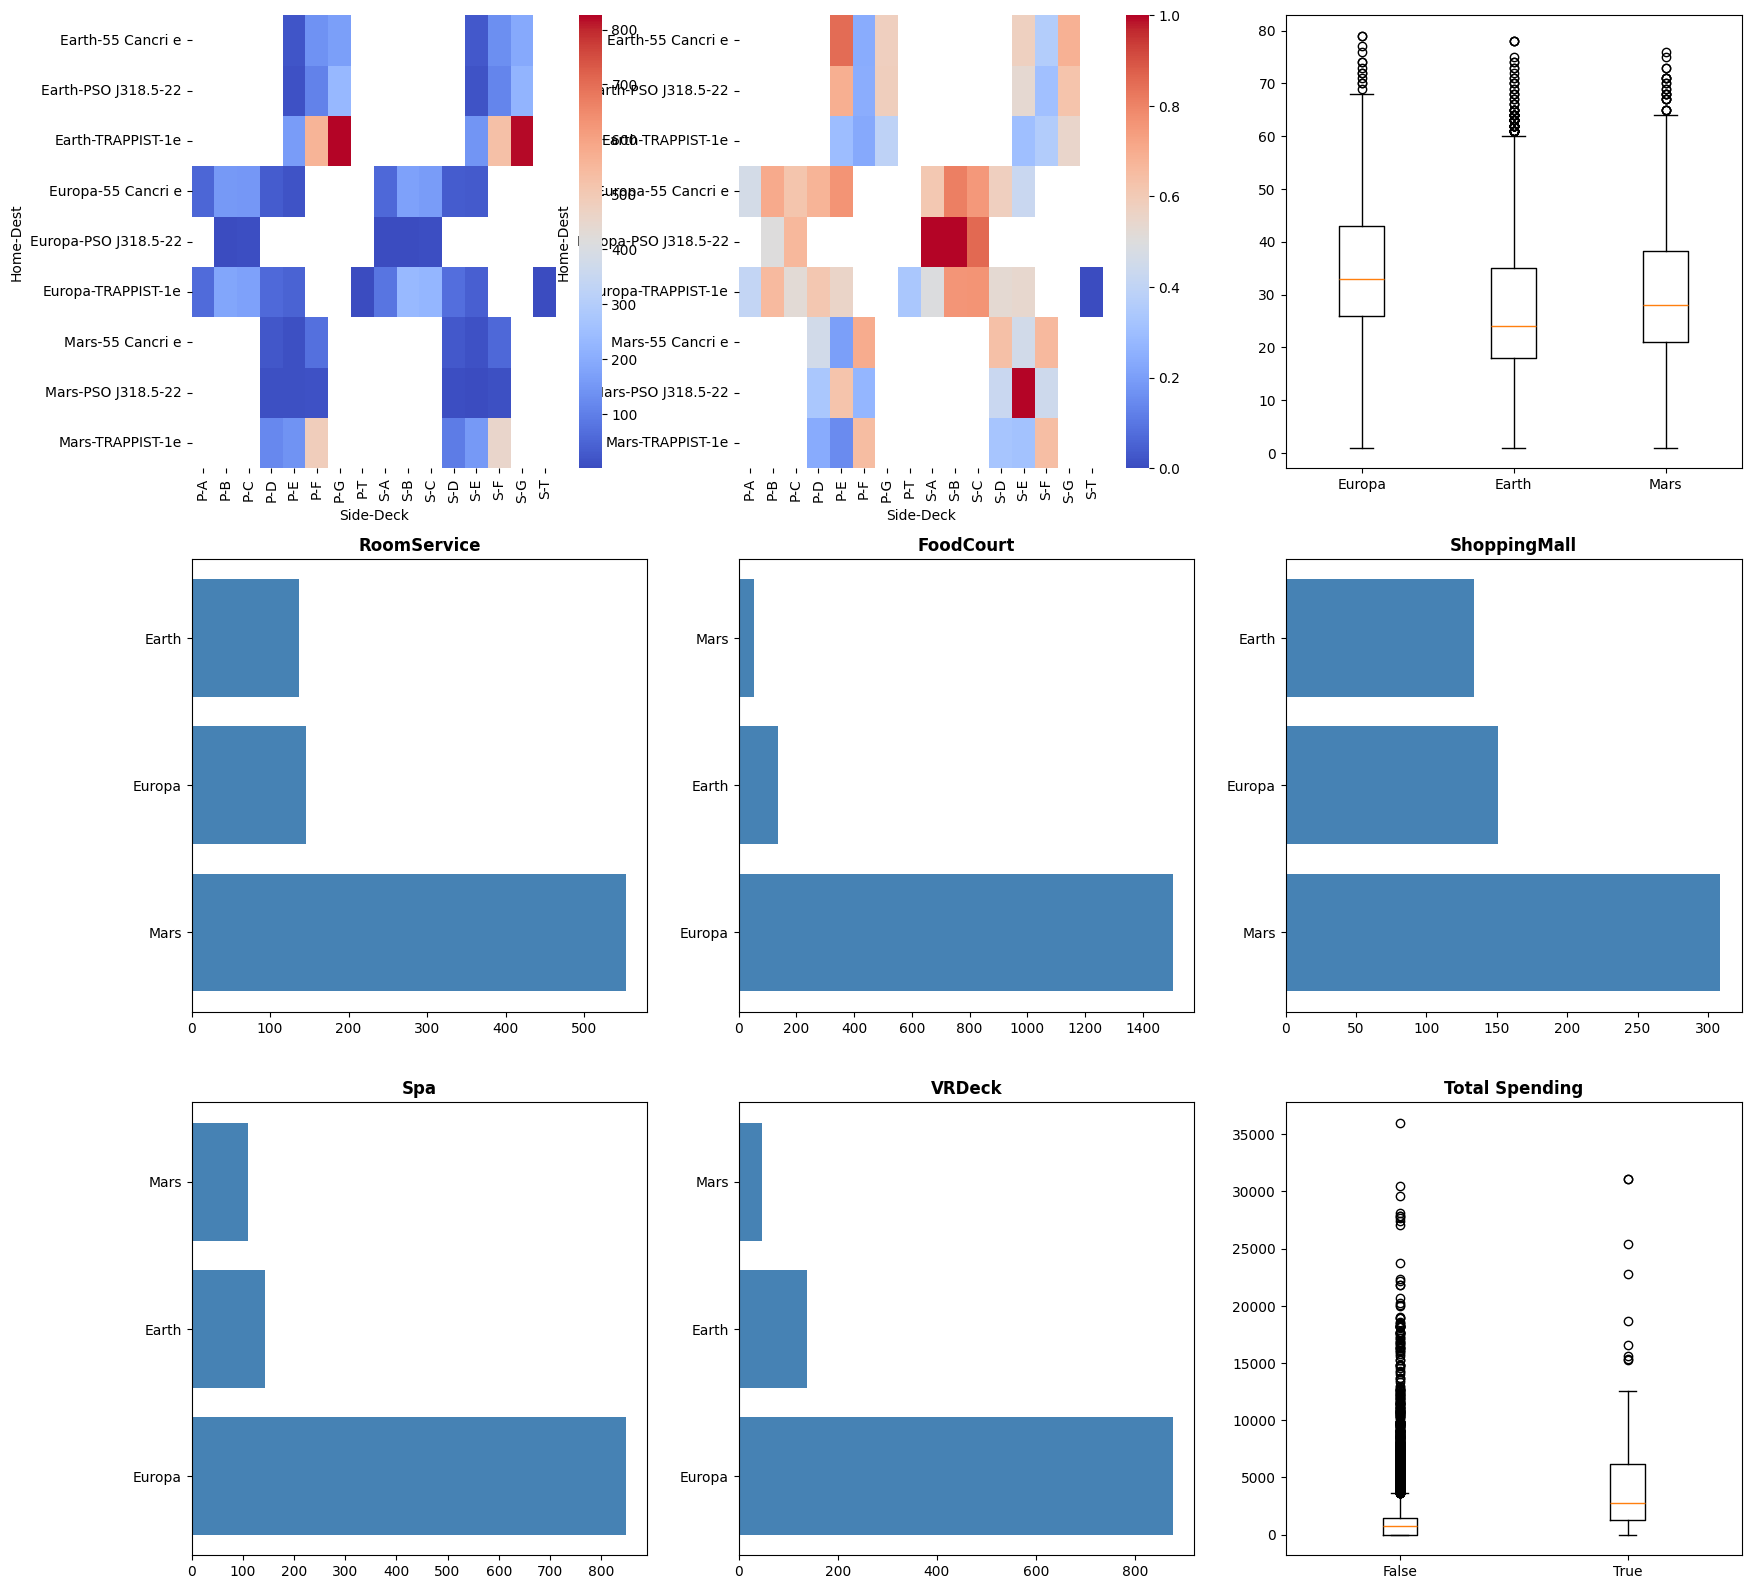

In [ ]:
df_eda = df_train.copy()
df_eda['Home-Dest'] = df_eda['HomePlanet'] + '-' + df_eda['Destination']
df_eda[['Deck' , 'CabinNum' , 'Side']] = df_eda['Cabin'].str.split('/', expand=True)
df_eda['Side-Deck'] = df_eda['Side'] + '-' + df_eda['Deck']
spend_features = ["RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck"]
df_eda['Total Spending'] = df_eda[spend_features].sum(axis=1)
df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=[0, 12, 18, 25, 35, 50, 100])
eda(df_eda, 3, 3, [
    {'Plot' : 'pivot_heatmap' , 'values' : 'Transported' , 'index' : 'Home-Dest', 'columns' : 'Side-Deck', 'annot' : False, 'agg_function' : 'count'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'Transported' , 'index' : 'Home-Dest', 'columns' : 'Side-Deck', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'boxplot' , 'columns' : 'HomePlanet', 'values' : 'Age'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'RoomService' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'RoomService'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'FoodCourt' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'FoodCourt'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'ShoppingMall' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'ShoppingMall'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'Spa' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'Spa'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'VRDeck' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'VRDeck'},
    {'Plot' : 'boxplot' , 'columns' : 'VIP' , 'values' : 'Total Spending' , 'title' : 'Total Spending'}
])

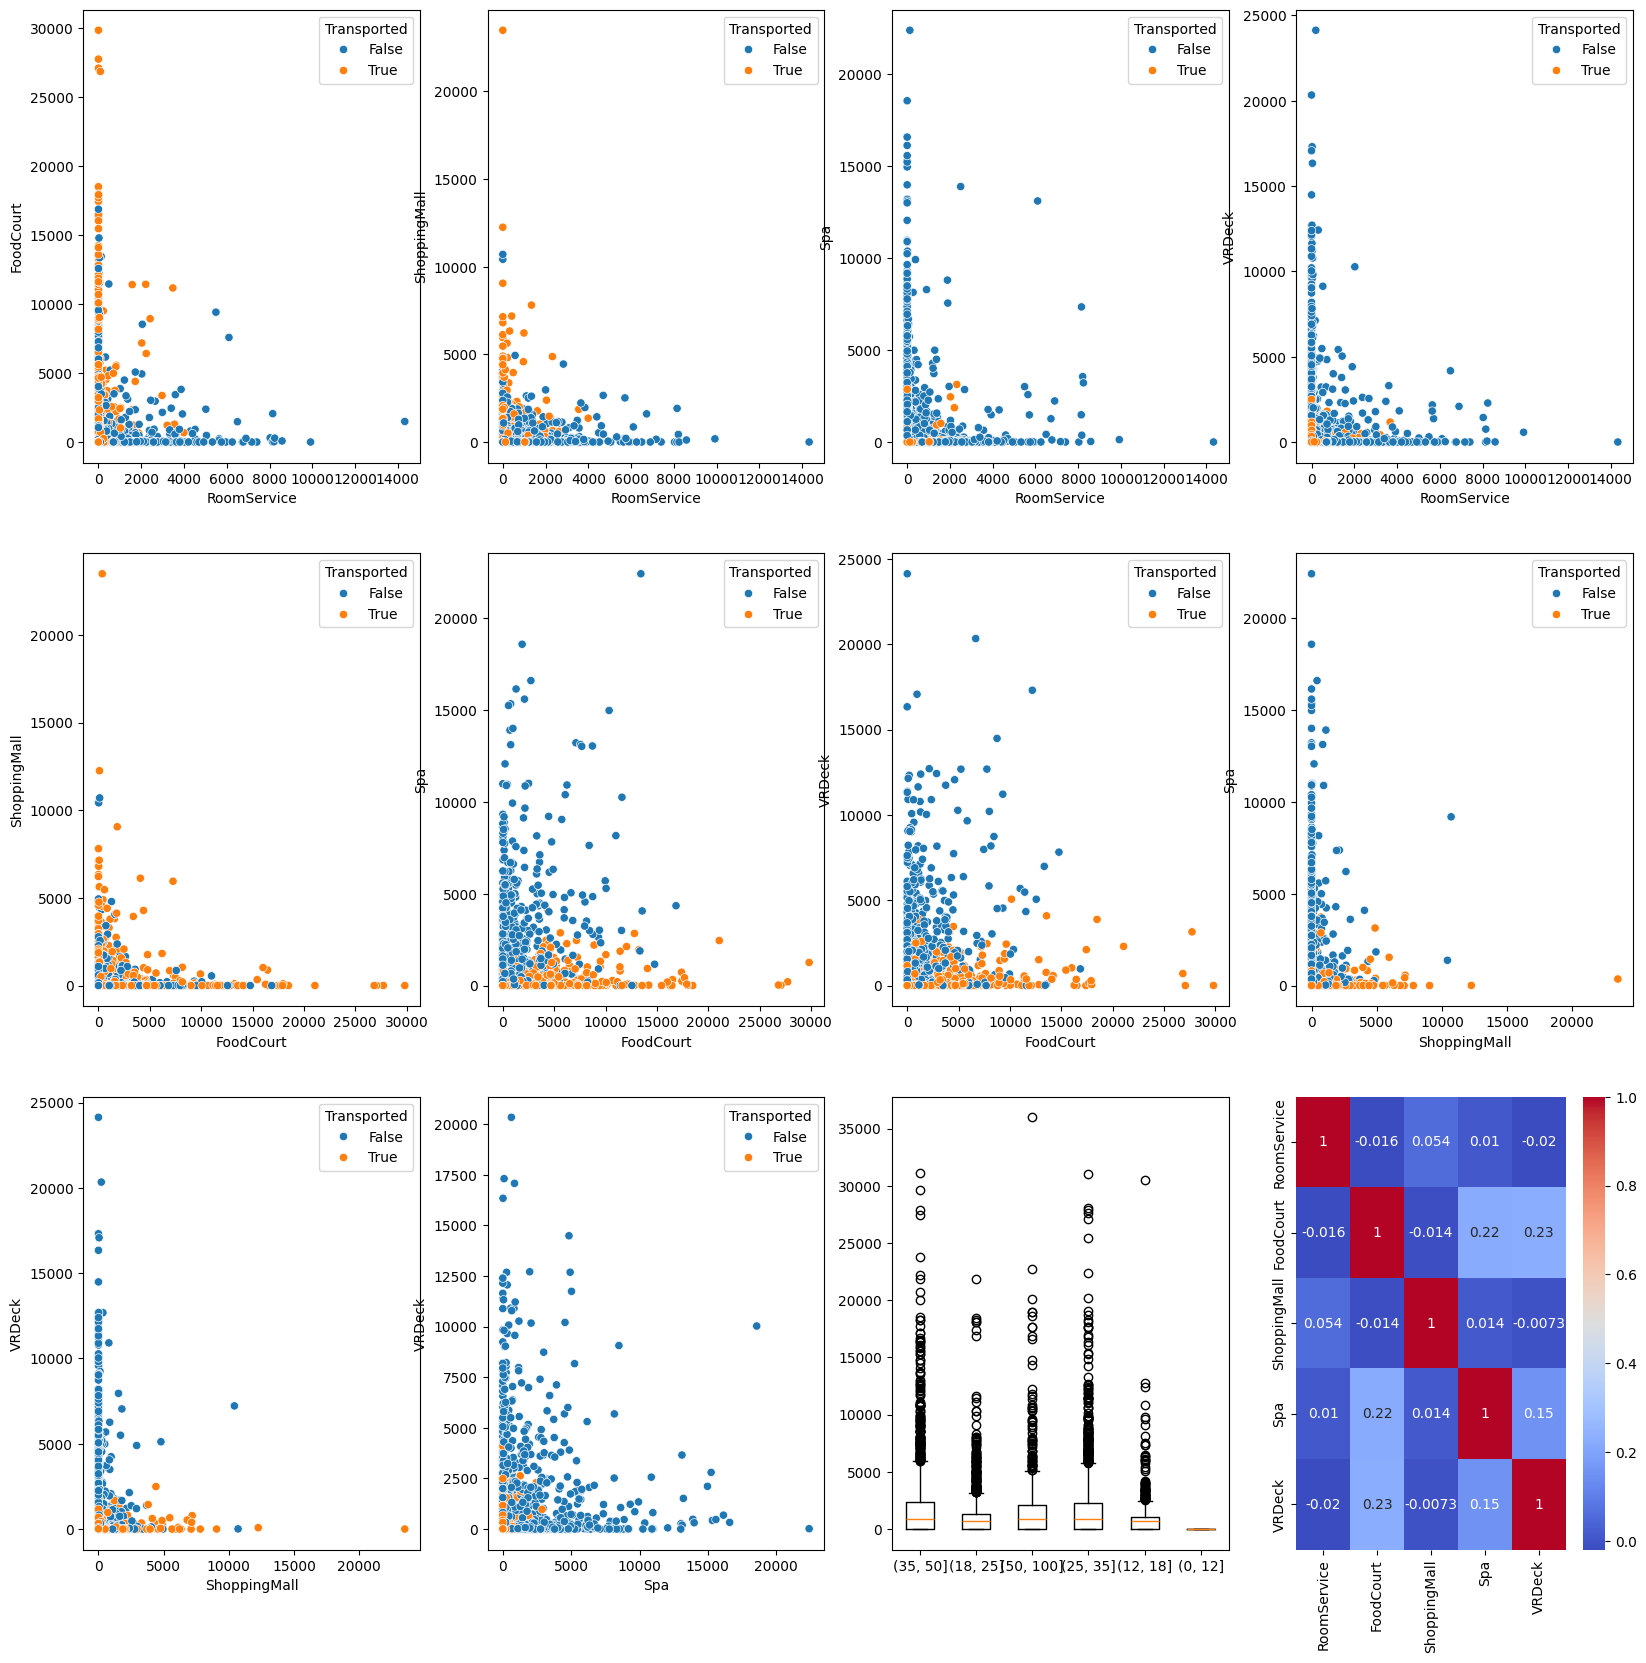

In [ ]:
eda(df_eda, 3, 4, [
    {'Plot' : 'scatter' , 'index' : 'RoomService' , 'columns' : 'FoodCourt' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'RoomService' , 'columns' : 'ShoppingMall' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'RoomService' , 'columns' : 'Spa' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'RoomService' , 'columns' : 'VRDeck' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'FoodCourt' , 'columns' : 'ShoppingMall' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'FoodCourt' , 'columns' : 'Spa' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'FoodCourt' , 'columns' : 'VRDeck' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'ShoppingMall' , 'columns' : 'Spa' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'ShoppingMall' , 'columns' : 'VRDeck' , 'values' : 'Transported'},
    {'Plot' : 'scatter' , 'index' : 'Spa' , 'columns' : 'VRDeck' , 'values' : 'Transported'},
    {'Plot' : 'boxplot' , 'columns' : 'AgeGroup', 'values' : 'Total Spending'},
    {'Plot' : 'corr' , 'columns' : spend_features}
])

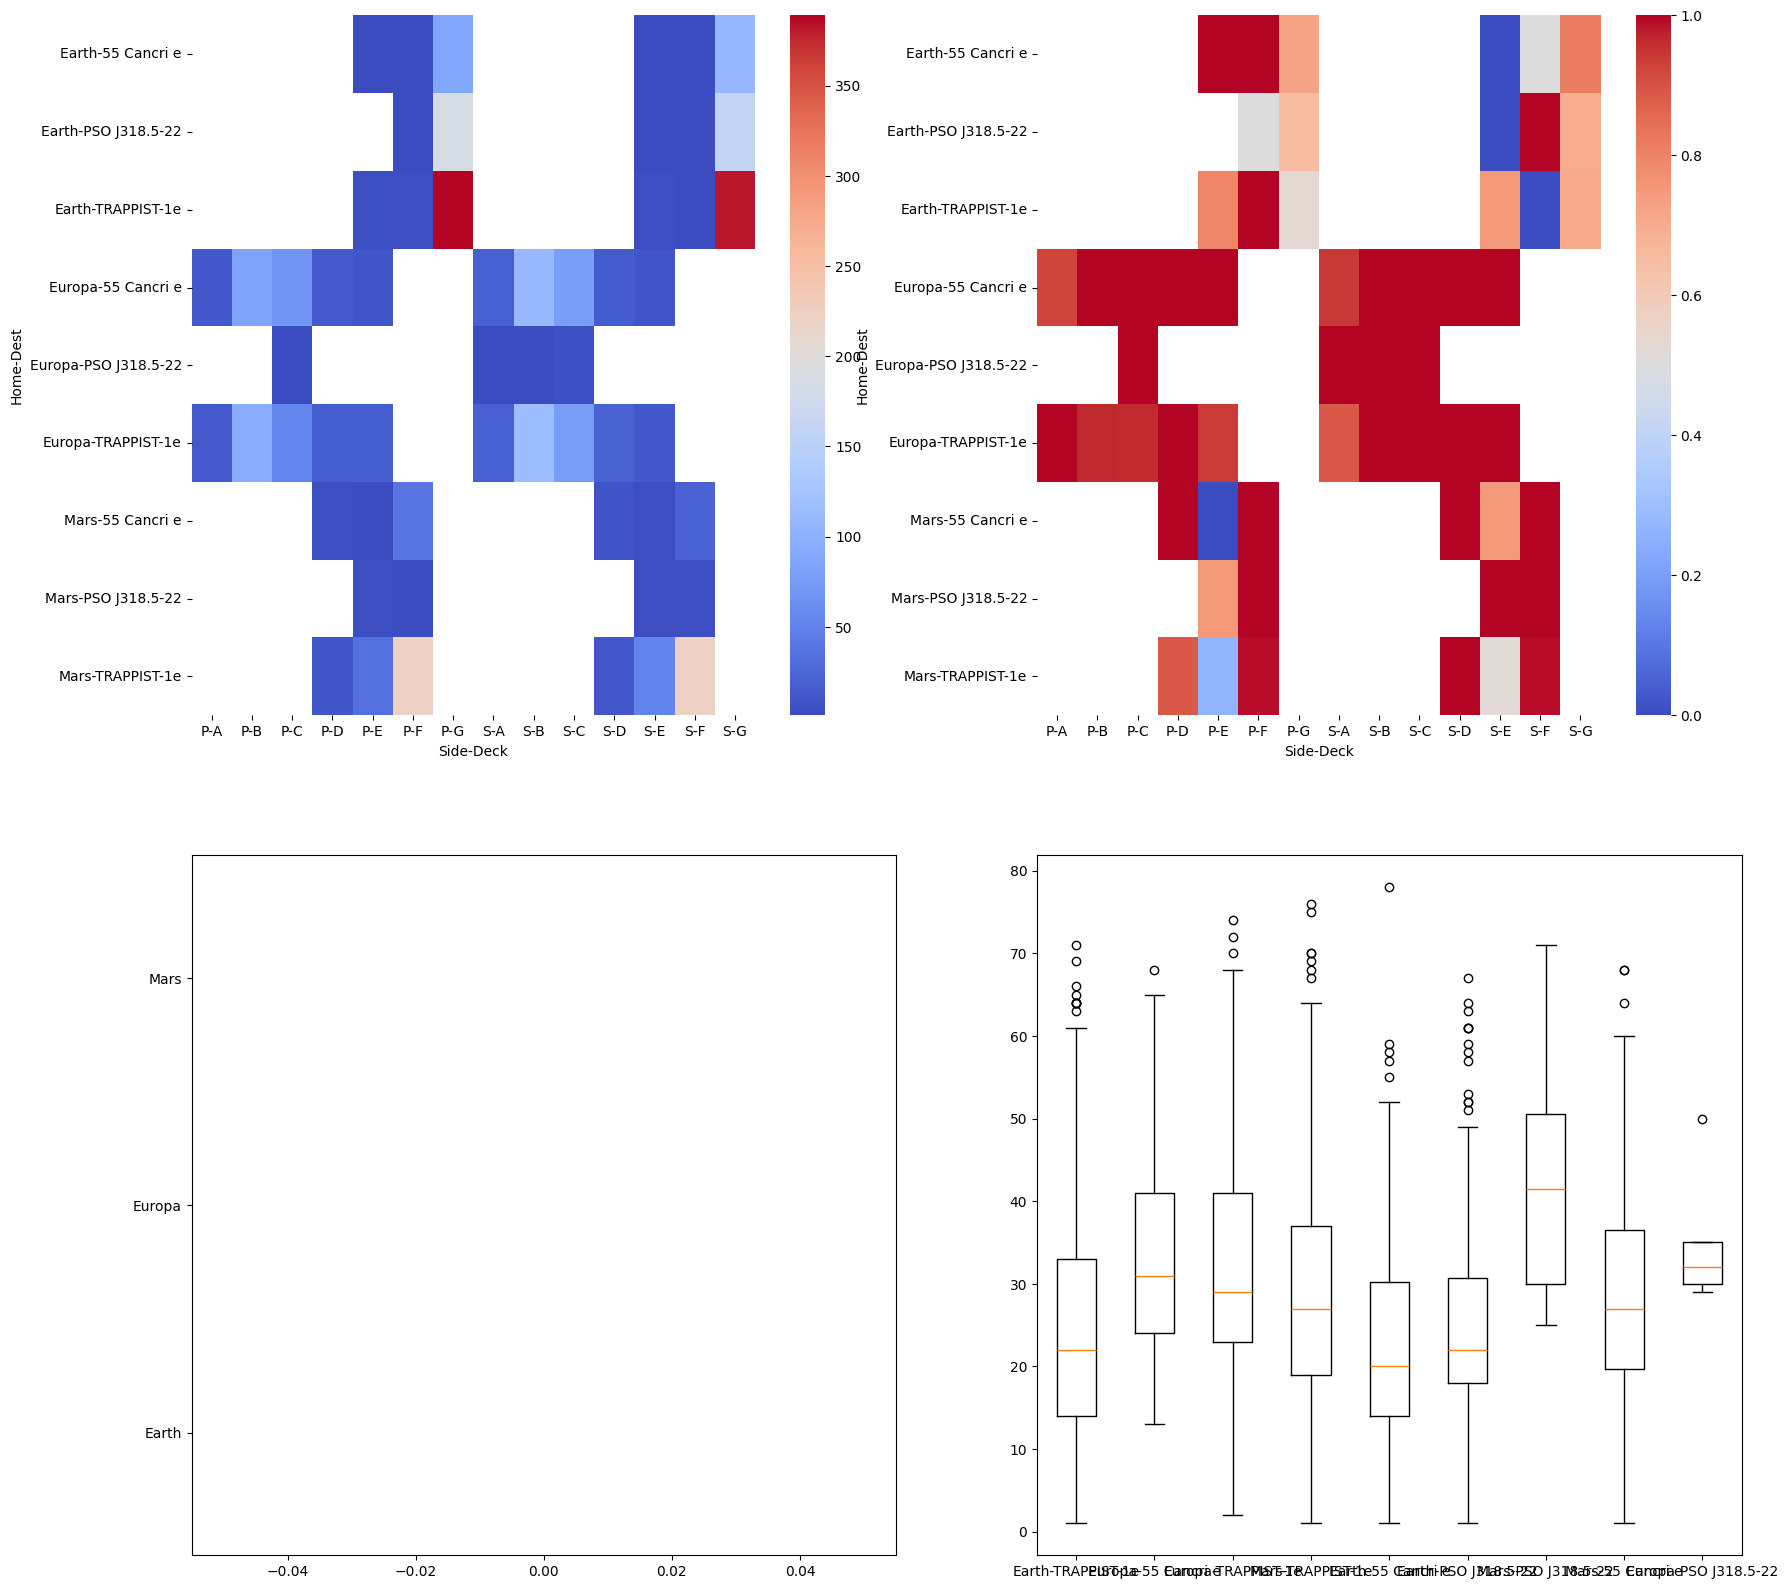

In [ ]:
eda(df_eda[df_eda['CryoSleep'] == True], 2, 2, [
    {'Plot' : 'pivot_heatmap' , 'values' : 'Transported' , 'index' : 'Home-Dest', 'columns' : 'Side-Deck', 'annot' : False, 'agg_function' : 'count'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'Transported' , 'index' : 'Home-Dest', 'columns' : 'Side-Deck', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'barh' , 'columns' : 'HomePlanet' , 'values' : 'Total Spending' , 'set_yticks' : True , 'set_yticklabels' : True},
    {'Plot' : 'boxplot' , 'columns' : 'Home-Dest', 'values' : 'Age'}
])

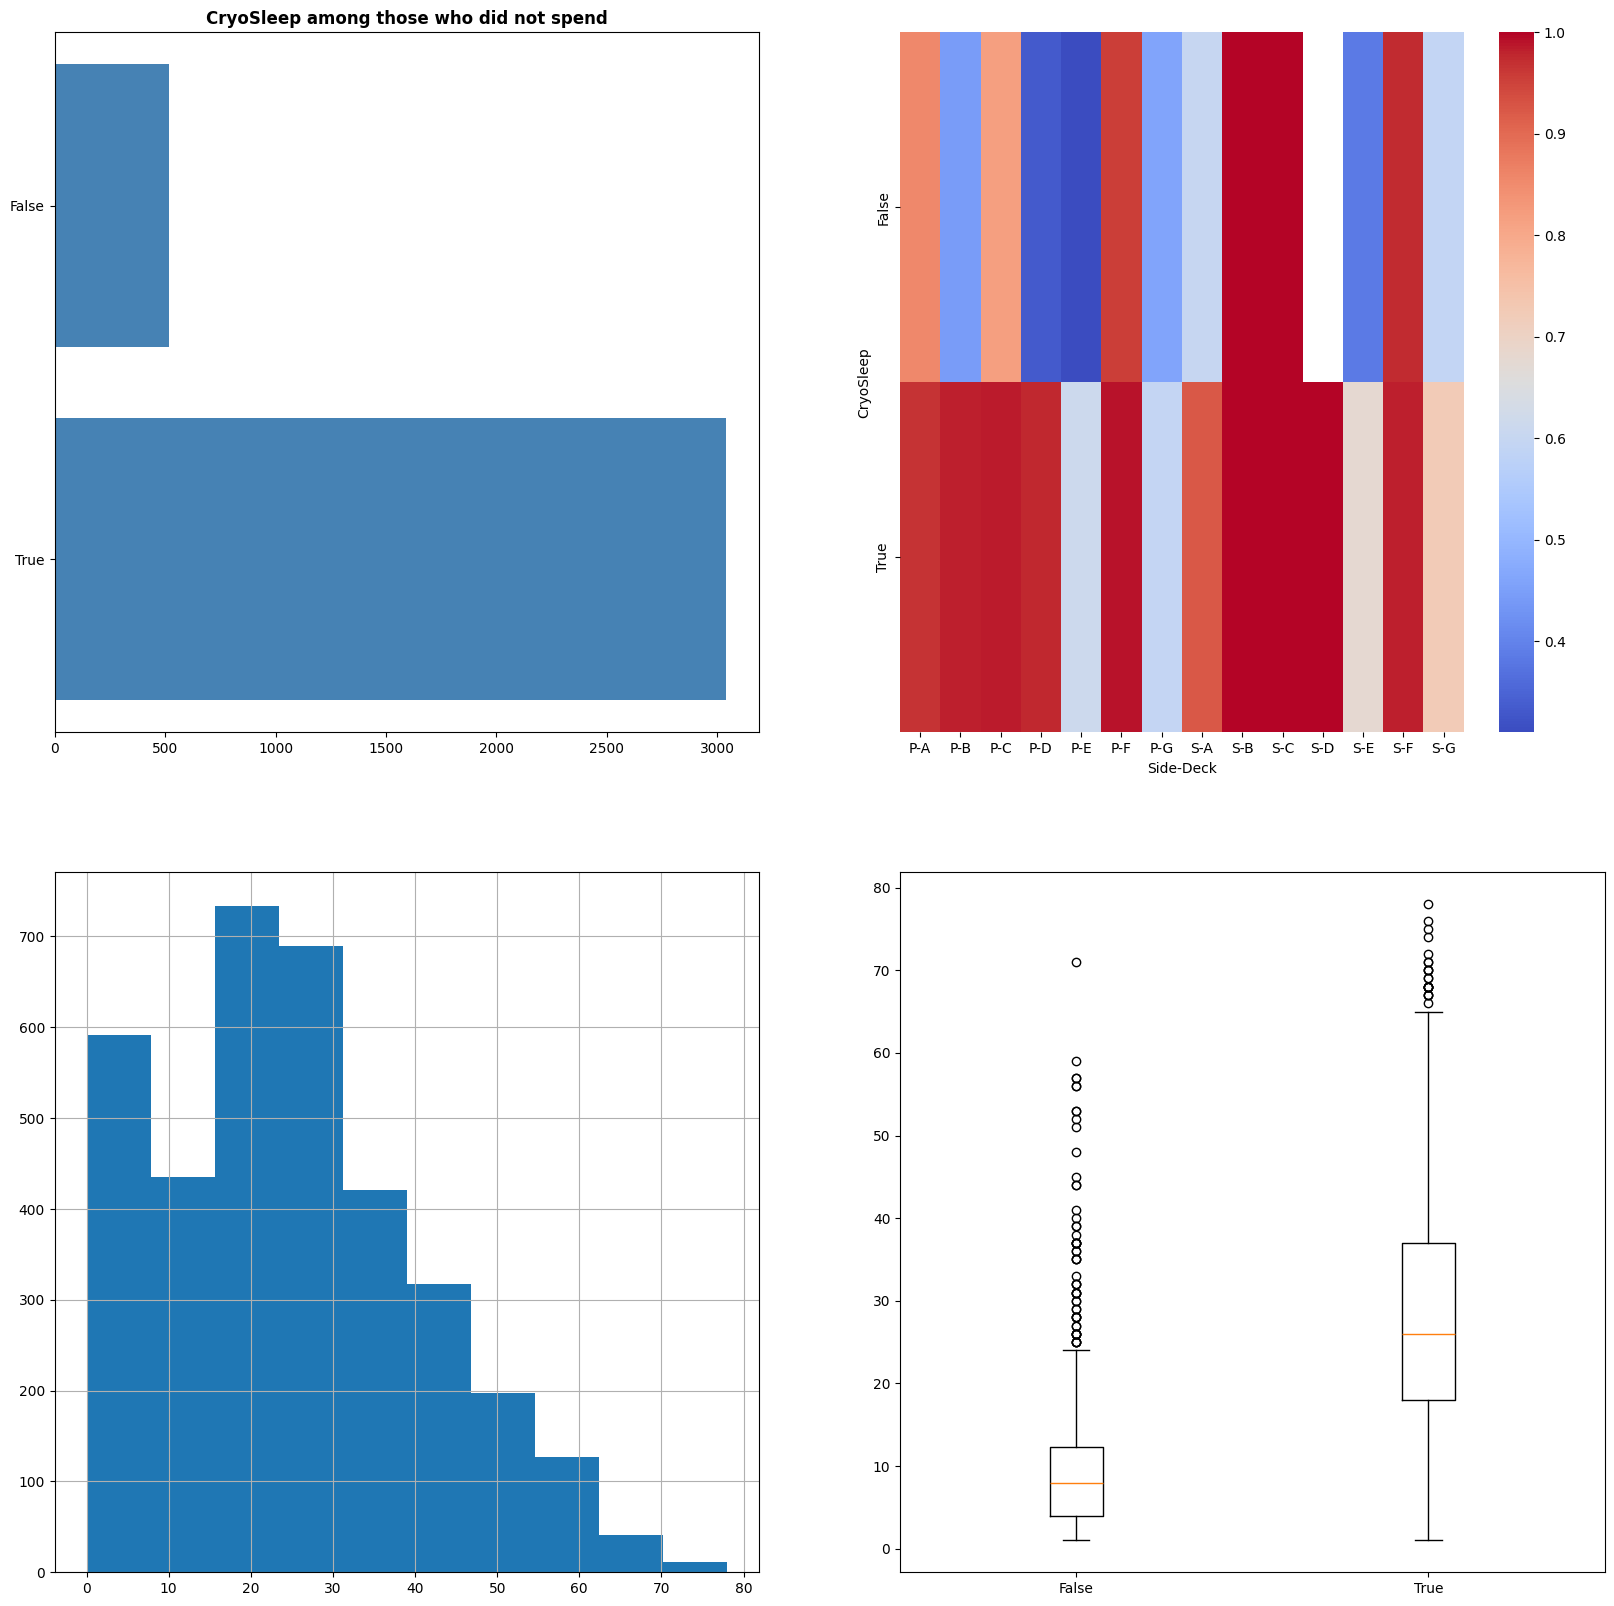

In [ ]:
eda(df_eda[df_eda['Total Spending'] == 0], 2, 2, [
    {'Plot' : 'barh' , 'columns' : 'CryoSleep' , 'values' : 'PassengerId' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'CryoSleep among those who did not spend', 'agg_function' : 'count'},
    {'Plot' : 'pivot_heatmap' , 'values' : 'Transported' , 'index' : 'CryoSleep', 'columns' : 'Side-Deck', 'annot' : False, 'agg_function' : 'mean'},
    {'Plot' : 'hist' , 'columns' : 'Age'},
    {'Plot' : 'boxplot' , 'columns' : 'CryoSleep', 'values' : 'Age'},
])

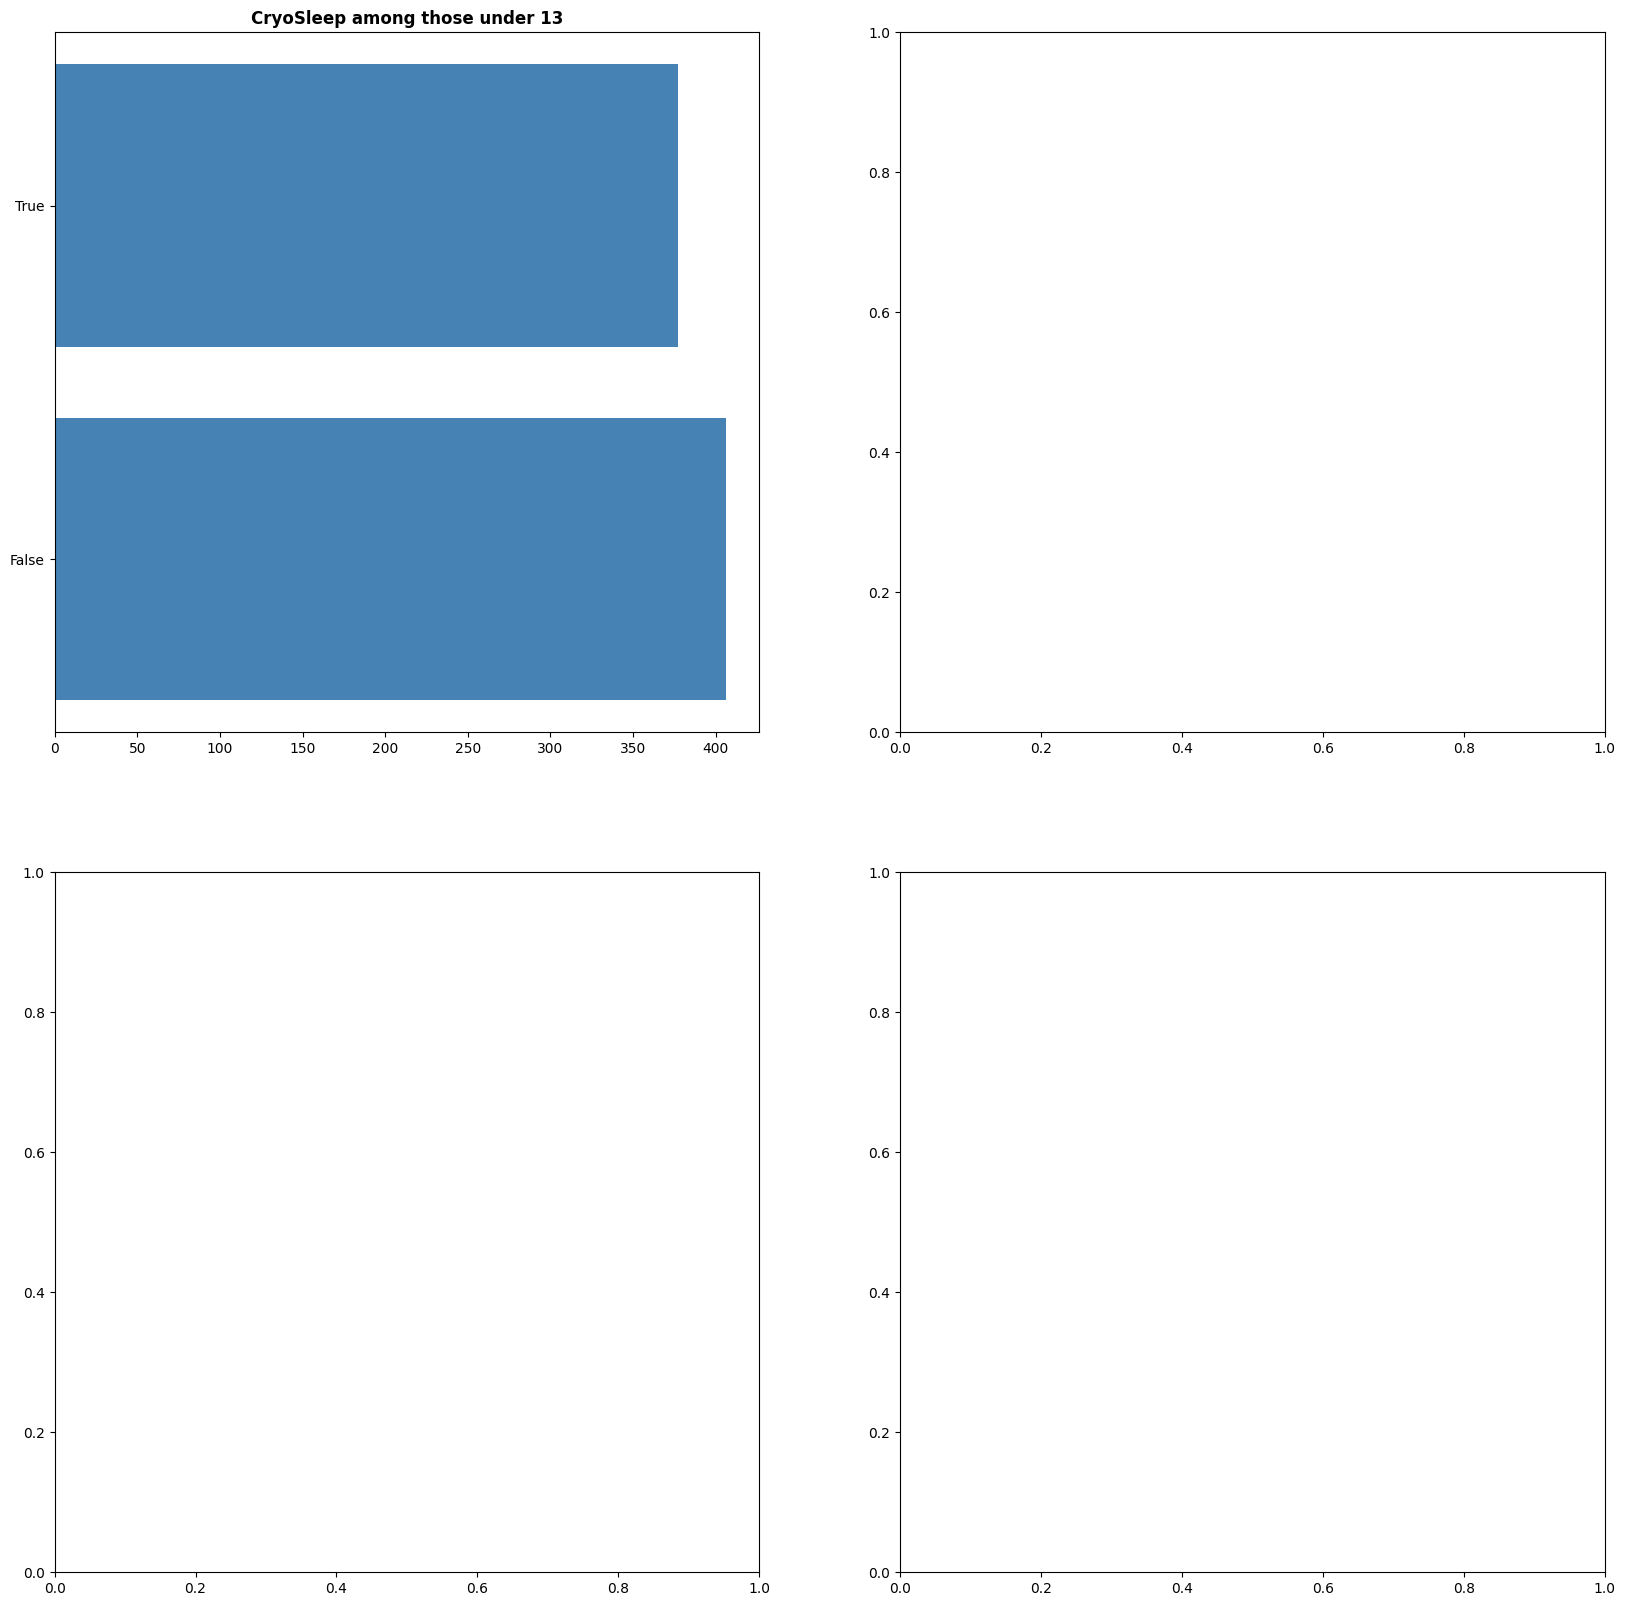

In [ ]:
eda(df_eda[df_eda['Age'] < 13], 2, 2, [
    {'Plot' : 'barh' , 'columns' : 'CryoSleep' , 'values' : 'PassengerId' , 'set_yticks' : True , 'set_yticklabels' : True , 'title' : 'CryoSleep among those under 13', 'agg_function' : 'count'},
])

- If CryoSleep is False or Age is under 12, spending is 0
- There is a strong correlation between the HomePlanet and where the cabin is located. Moreover, spcecially on people in CryoSleep, there is a strong correlation between cabin location and whether a passenger was transported.
- Spending in FoodCourt, Spa and VRDeck is somewhat correlated. More interestingly, spending habits are quite correlated with HomePlanet, and, of course, VIP status
- FoodCourt and ShoppingMall spending is quite correlated to being transported

# Imputation

In [ ]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [ ]:
# First we fill with zeroes Nans in spending cols for passengers in CryoSleep or under 12
# Conversely, Nans in CryoSleep of people who have spent are filled with False
# First, we fill HomePlanet, Destination, VIP, Cabin with group median (spending cols are not filled to not underestimate the spending of parents due to childrens in their groups)
# As we saw during EDA, HomePlanet is correlated with cabin deck, we fill Nans with the mode of their Deck, and vice versa
# Spending is correlated with HomePlanet, to fill it, we group by HomePlanet and fill with the mean
# Those who did not spend are very likely to be in CryoSleep (unless they are under 12)
# Name column will be dropped so we do not need to impute
# Lastly, we impute remaining data using KNN imputation
class SmartImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.info_by_group_cols = ['HomePlanet', 'Destination', 'VIP', 'Cabin']
        self.info_by_group = {}
    def fit(self, X, y=None):
        df = X.copy()
        df['GroupId'] = df['PassengerId'].str.split('_').str[0]
        self.info_by_group = df.groupby('GroupId')[self.info_by_group_cols].apply(lambda x : {col : x[col].mode()[0] if not x[col].mode().empty else np.nan for col in self.info_by_group_cols}).to_dict()
        df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
        self.deck_by_planet = df.groupby('HomePlanet')['Deck'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan).to_dict()
        self.planet_by_deck = df.groupby('Deck')['HomePlanet'].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan).to_dict()
        spend_cols = ["RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck"]
        self.spending_by_planet = df.groupby('HomePlanet')[spend_features].apply(lambda x: {col: x[col].mean() for col in spend_cols})
        
        df['Total Spending'] = df[spend_cols].sum(axis=1)
        num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Total Spending']
        
        self.knn = KNNImputer().fit(df[num_cols])

        return self

    def transform(self, X):
        df = X.copy()
        spend_cols = ["RoomService" , "FoodCourt" , "ShoppingMall" , "Spa" , "VRDeck"]
        for col in spend_cols:
            mask = ((df['CryoSleep'] == True) | (df['Age'] < 13)) & (df[col].isnull())
            df.loc[mask,col] = 0.0
            mask = (df[col] > 0) & (df['CryoSleep'].isnull())
            df.loc[mask,'CryoSleep'] = False
        df['GroupId'] = df['PassengerId'].str.split('_').str[0]
        for group, info in self.info_by_group.items():
            premask = df['GroupId']==group
            for col in self.info_by_group_cols:
                mask = premask & (df[col].isnull())
                df.loc[mask, col] = info[col]
        df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
        for planet, deck in self.deck_by_planet.items():
            mask = (df['HomePlanet'] == planet) & (df['Deck'].isnull())
            df.loc[mask, 'Deck'] = deck
        for deck, planet in self.planet_by_deck.items():
            mask = (df['Deck'] == deck) & (df['HomePlanet'].isnull())
            df.loc[mask, 'HomePlanet'] = planet
        for planet, planet_spending in self.spending_by_planet.items():
            for col in spend_cols:
                mask = (df['HomePlanet'] == planet) & (df[col].isnull())
                df.loc[mask, col] = planet_spending[col]
        df['Total Spending'] = df[spend_cols].sum(axis=1)
        mask = (df['Total Spending'] == 0.0) & (df['CryoSleep'].isnull())
        df.loc[mask, 'CryoSleep'] = True

        df['GroupSize'] = df.groupby('GroupId')['GroupId'].transform('count').astype(int)
        df['IsAlone'] = (df['GroupSize'] == 0)

        df['CabinNum'] = df['CabinNum'].astype(float).fillna(0)
        bool_cols = ['CryoSleep', 'VIP', 'IsAlone']
        cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
        num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Total Spending']

        for col in bool_cols + cat_cols:
            df[col] = df[col].fillna(df[col].mode()[0])
        df[num_cols] = self.knn.transform(df[num_cols])
        df['Total Spending'] = df[spend_cols].sum(axis=1)
        df[bool_cols] = df[bool_cols].astype(int)
        return df.drop(columns=['Name' , 'Cabin', 'GroupId', 'PassengerId'])

In [ ]:
bool_cols = ['CryoSleep', 'VIP', 'IsAlone']
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
num_cols = ['CabinNum', 'GroupSize', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Total Spending']
preprocessor = Pipeline([
    ('imputer', SmartImputer()),
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(sparse_output=False))
        ]), cat_cols)
    ], remainder='passthrough').set_output(transform='pandas'))
])

In [ ]:
def get_models(nn_shape):
    l1=1e-3
    l2=1e-2
    nn_model1 = Sequential()
    nn_model1.add(Input(shape=(nn_shape,)))
    nn_model1.add(Dense(units=64, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model1.add(Dropout(0.3))
    nn_model1.add(Dense(units=32, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model1.add(Dropout(0.2))
    nn_model1.add(Dense(units=32, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model1.add(Dropout(0.2))
    nn_model1.add(Dense(units=1, activation="sigmoid"))
    nn_model1.compile(optimizer="adam" , loss="binary_crossentropy" , metrics=["accuracy"])
    nn_model2 = Sequential()

    nn_model2.add(Input(shape=(nn_shape,)))
    nn_model2.add(Dense(units=16, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model2.add(Dropout(0.3))
    nn_model2.add(Dense(units=8, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model2.add(Dropout(0.2))
    nn_model2.add(Dense(units=4, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)))
    nn_model2.add(Dropout(0.2))
    nn_model2.add(Dense(units=1, activation="sigmoid"))
    nn_model2.compile(optimizer="adam" , loss="binary_crossentropy" , metrics=["accuracy"])

    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1, class_weight='balanced'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, eval_metric='logloss', verbosity=0
        ),
        'SVM': SVC(
            kernel='rbf', C=1.0, gamma='scale', probability=True,
            class_weight='balanced', random_state=42
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=100, max_depth=7, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, verbose=-1
        ),
        'KNN' : KNeighborsClassifier(n_neighbors=3),
        'AdaBoost' : AdaBoostClassifier(
            n_estimators=100, random_state=42, learning_rate=0.1
        ),
        'NN1' : nn_model1,
        'NN2' : nn_model2
    }

In [ ]:
X = preprocessor.fit_transform(df_train.drop(columns=['Transported']))
y = df_train['Transported']
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
classifiers = get_models(nn_shape = X.shape[1])

for clf_name, clf in classifiers.items():
    try:
        if clf_name == 'NN1' or clf_name == 'NN2':
            clf.fit(X_tr, y_tr , epochs=25 , batch_size = 8 , validation_data=(X_val, y_val), verbose = 1)
            continue
        else:
            clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        if hasattr(clf, 'predict_proba'):
            y_pred_proba = clf.predict_proba(X_val)[:,1]
        else:
            y_pred_proba = clf.decision_function(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        print(f'  {clf_name:20} | Acc: {accuracy:.4f} | F1: {f1:.4f} | ROC: {roc_auc:.4f}')
    except Exception as e:
        print(f'  {clf_name:20} | ERROR: {str(e)[:50]}')


  Logistic Regression  | Acc: 0.7901 | F1: 0.7927 | ROC: 0.8830
  Random Forest        | Acc: 0.8091 | F1: 0.8042 | ROC: 0.9042
  XGBoost              | Acc: 0.8160 | F1: 0.8171 | ROC: 0.9126
  SVM                  | Acc: 0.7976 | F1: 0.7953 | ROC: 0.8885
  LightGBM             | Acc: 0.8148 | F1: 0.8152 | ROC: 0.9134
  KNN                  | Acc: 0.7763 | F1: 0.7742 | ROC: 0.8382
  AdaBoost             | Acc: 0.7493 | F1: 0.7295 | ROC: 0.8404
Epoch 1/25
870/870 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7285 - loss: 0.5363 - val_accuracy: 0.7861 - val_loss: 0.4370
Epoch 2/25
870/870 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7872 - loss: 0.4565 - val_accuracy: 0.8010 - val_loss: 0.4156
Epoch 3/25
870/870 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7918 - loss: 0.4519 - val_accuracy: 0.7993 - val_loss: 0.4142
Epoch 4/25
870/870 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7990 - loss: 0.4380 - val_accuracy: 0.7976 - val_loss: 0.4138
Epoch 5/25
870/870 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
top_classifiers = ['Random Forest', 'XGBoost', 'LightGBM', 'NN1', 'NN2', 'SVM', 'Logistic Regression']
ensemble_dict = {}
classifiers = get_models(nn_shape = X.shape[1])
for name in top_classifiers:
    if name == 'NN1' or name == 'NN2':
        clf = KerasClassifier(model=classifiers[name], epochs=25, batch_size=8, verbose=0)
        clf.fit(X,y)
    else:
        clf = classifiers[name]
        clf.fit(X, y)

    ensemble_dict[name] = clf
    print(f'✔ {name} trained')
ensemble = VotingClassifier(
    estimators=[(name, ensemble_dict[name]) for name in top_classifiers],
    voting='soft'
)
ensemble.fit(X, y)
ensemble_train_score = ensemble.score(X, y)
print(f'✔ Ensemble training accuracy: {ensemble_train_score:.4f}')

X_test = preprocessor.transform(df_test)
y_pred_test = ensemble.predict(X_test)

submission = pd.DataFrame({
    'PassengerId' : df_test['PassengerId'],
    'Transported' : y_pred_test
})
submission.to_csv('submission.csv', index=False)

✔ Random Forest trained
✔ XGBoost trained
✔ LightGBM trained
✔ NN1 trained
✔ NN2 trained
✔ SVM trained
✔ Logistic Regression trained
✔ Ensemble training accuracy: 0.8690
